# Python for Data Science/Analysis
Using various libraries of python for statistical analysis.
We will be using the Student Sleep Patterns Dataset from Kaggle to explore these libraries.
https://www.kaggle.com/datasets/arsalanjamal002/student-sleep-patterns

### Agenda:
1. Python basics
2. NumPy: vectorized operations
3. Pandas: managing structured data
4. Statsmodels & SciPy: performing statistical inference
5. Seaborn: visualizing distributions and relationships

Make sure python is installed! 

Run the following in your terminal to install the necessary packages:

```pip install numpy pandas statsmodels seaborn ipykernel```


### Part 1:
If you want to get this notebook, go to: https://github.com/akoduru727/STATS598C-presentation

Python is "dynamically typed" and relies on indentation to define blocks of code.

Dynamic typing: Variable types are checked at runtime rather than during compilation. This means that variables can hold different data types over their lifecycle and do not require explicit type declarations other programming languages (Java, C++).

In [40]:
# Variables and Math
sleep_goal = 8 
caffeine_limit = 200.5

# Python lists
caffeine_list = [100, 200, 300]

# Lists are NOT vectors. 
# Attempting to multiply a list results in duplication of the list:
print("List 'math' (Duplication):", caffeine_list * 2)

# Loops and indenting code blocks
for amount in caffeine_list:
    if amount > 150:
        print(f"High intake detected: {amount}mg")

List 'math' (Duplication): [100, 200, 300, 100, 200, 300]
High intake detected: 200mg
High intake detected: 300mg


### Part 2
NumPy provides the ndarray, which allows for "vectorized" operations (performing math on every element at once without loops).

In [41]:
import numpy as np

# Making a numpy array instead of a python list
caffeine_arr = np.array([100, 200, 300])

# vectorized multiplication (now we can multiply the array)
print("Array multiplication:", caffeine_arr * 2)

# common functions
print("Mean Intake:", np.mean(caffeine_arr))
print("Standard Deviation:", np.std(caffeine_arr))

Array multiplication: [200 400 600]
Mean Intake: 200.0
Standard Deviation: 81.64965809277261


### Part 3

In [ ]:
import pandas as pd

# loading data
df = pd.read_excel('student_sleep_patterns.csv')

df = pd.DataFrame()

# inspecting dimensions
print(f"Dataset Shape: {df.shape}") # Rows, Columns

Dataset Shape: (500, 14)


In [43]:
# statistical summary
# like summary() in R
print(df.describe())

       Student_ID        Age  Sleep_Duration  Study_Hours  Screen_Time  \
count  500.000000  500.00000      500.000000   500.000000   500.000000   
mean   250.500000   21.53600        6.472400     5.981600     2.525000   
std    144.481833    2.33315        1.485764     3.475725     0.859414   
min      1.000000   18.00000        4.000000     0.100000     1.000000   
25%    125.750000   20.00000        5.100000     2.900000     1.800000   
50%    250.500000   21.00000        6.500000     6.050000     2.600000   
75%    375.250000   24.00000        7.800000     8.800000     3.300000   
max    500.000000   25.00000        9.000000    12.000000     4.000000   

       Caffeine_Intake  Physical_Activity  Sleep_Quality  Weekday_Sleep_Start  \
count       500.000000         500.000000     500.000000           500.000000   
mean          2.462000          62.342000       5.362000            11.166860   
std           1.682325          35.191674       2.967249             5.972352   
min      

In [44]:
# grouping data by columns
# let's see if average sleep quality differs by Gender
# useful to observe data in chunks
print(df.groupby('Gender')['Sleep_Quality'].mean())

Gender
Female    5.554217
Male      5.102151
Other     5.472973
Name: Sleep_Quality, dtype: float64


### Part 4

In [45]:
from scipy import stats
import statsmodels.formula.api as smf

# hypothesis Testing: T-Test
# Does Sleep_Duration differ between Men and Women in this sample?
male_sleep = df[df['Gender'] == 'Male']['Sleep_Duration']
female_sleep = df[df['Gender'] == 'Female']['Sleep_Duration']

t_stat, p_val = stats.ttest_ind(male_sleep, female_sleep)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

T-statistic: -1.0906, P-value: 0.2762


In [46]:
# multiple Linear Regression
# Sleep_Quality is predicted by Caffeine, Study Hours, and Screen Time
# summary table is printed
model = smf.ols('Sleep_Quality ~ Caffeine_Intake + Study_Hours + Screen_Time', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Sleep_Quality   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.6079
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.610
Time:                        14:06:00   Log-Likelihood:                -1251.9
No. Observations:                 500   AIC:                             2512.
Df Residuals:                     496   BIC:                             2529.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.9896      0.508     

#### Part 5

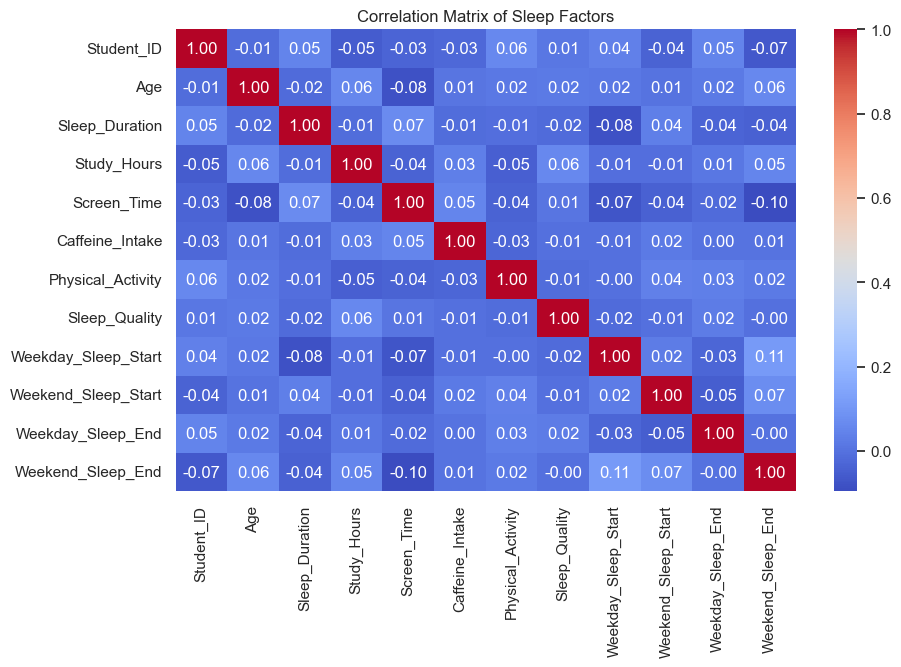

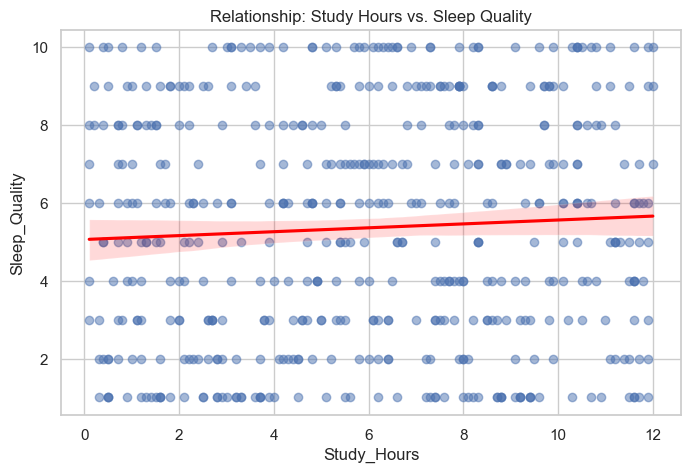

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# correlation matrix heatmap
# usually useful for identifying multicollinearity
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Sleep Factors")
plt.show()

# regression plot
# visualizing the relationship between Study Hours and Sleep Quality
plt.figure(figsize=(8, 5))
sns.regplot(x='Study_Hours', y='Sleep_Quality', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Relationship: Study Hours vs. Sleep Quality")
plt.show()

### Resources

I find myself constantly referring to the following documentation:
- https://pandas.pydata.org/docs/
- https://www.statsmodels.org/
- https://seaborn.pydata.org/tutorial/introduction.html

Other Libraries:
- Machine Learning: http://scikit-learn.org/

I also like this resource for learning!
- https://jakevdp.github.io/PythonDataScienceHandbook/